# How to use Pandas `.pipe()` method

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Mock data 1

In [2]:
df = pd.DataFrame.from_dict(
    {
        "text": ["abc-01", "cDe 02", "Efg_03", np.nan],
        "Number1": [1, 6, 10, 5],
        "Number2": [59.99, 14.99, 9.99, 23.99],
    }
)

df

,text,Number1,Number2
0,abc-01,1,59.99
1,cDe 02,6,14.99
2,Efg_03,10,9.99
3,NaN,5,23.99


In [3]:
print(df.to_markdown(tablefmt="simple"))

    text      Number1    Number2
--  ------  ---------  ---------
 0  abc-01          1      59.99
 1  cDe 02          6      14.99
 2  Efg_03         10       9.99
 3  nan             5      23.99


### Old way

In [4]:
# Rename columns
df = df.rename(
    columns={
        "text": "product_code",
        "Number1": "quantity",
        "Number2": "unit_price_usd",
    }
)

# Remove nans
df = df.dropna().reset_index(drop=True)

# Stanardize product names
df["product_code"] = (
    df["product_code"]
    .str.upper()
    .str.replace("-", "_")
    .str.replace(" ", "_")
)

# Add new columns
df["total_sales_usd"] = df["quantity"] * df["unit_price_usd"]
df["total_percentage_sale"] = (
    (
        (df["total_sales_usd"] / df["total_sales_usd"].sum())*100
    )
    .round(1)
    .astype("str")
    + "%"
)

# Sort the data
df = (
    df
    .sort_values(by="total_sales_usd", ascending=False)
    .reset_index(drop=True)
)

df


,product_code,quantity,unit_price_usd,total_sales_usd,total_percentage_sale
0,EFG_03,10,9.99,99.90,40.0%
1,CDE_02,6,14.99,89.94,36.0%
2,ABC_01,1,59.99,59.99,24.0%


In [5]:
print(df.to_markdown(tablefmt="simple"))

    product_code      quantity    unit_price_usd    total_sales_usd  total_percentage_sale
--  --------------  ----------  ----------------  -----------------  -----------------------
 0  EFG_03                  10              9.99              99.9   40.0%
 1  CDE_02                   6             14.99              89.94  36.0%
 2  ABC_01                   1             59.99              59.99  24.0%


### Pipe way 1 - using user defined functions

In [6]:
# Let's reset the DataFrame
df = pd.DataFrame.from_dict(
    {
        "text": ["abc-01", "cDe 02", "Efg_03", np.nan],
        "Number1": [1, 6, 10, 5],
        "Number2": [59.99, 14.99, 9.99, 23.99],
    }
)

df

,text,Number1,Number2
0,abc-01,1,59.99
1,cDe 02,6,14.99
2,Efg_03,10,9.99
3,NaN,5,23.99


In [7]:
# Define functions to manipulate the DataFrame

def rename_columns(df: pd.DataFrame) -> pd.DataFrame:
    return df.rename(
        columns={
            "text": "product_code",
            "Number1": "quantity",
            "Number2": "unit_price_usd",
        }
    )


def remove_nans(df: pd.DataFrame) -> pd.DataFrame:
    return df.dropna().reset_index(drop=True)


def standardize_product_codes(df: pd.DataFrame) -> pd.DataFrame:
    clean_codes = (
        df["product_code"]
        .str.upper()
        .str.replace("-", "_")
        .str.replace(" ", "_")
    )
    return df.assign(product_code=clean_codes)


def calculate_sales_metrics(df: pd.DataFrame) -> pd.DataFrame:
    total_sales = df["quantity"] * df["unit_price_usd"]
    pct_of_total = (total_sales / total_sales.sum()) * 100
    pct_formatted = pct_of_total.round(1).astype(str) + "%"

    return df.assign(
        total_sales_usd=total_sales,
        total_percentage_sale=pct_formatted
    )


def sort_by_sales(df, ascending=False):
    return (
        df
        .sort_values(
            by="total_sales_usd",
            ascending=ascending
        )
        .reset_index(drop=True)
    )


#  Assemble and run the pipeline
df_final = (
    df
    .pipe(rename_columns)
    .pipe(remove_nans)
    .pipe(standardize_product_codes)
    .pipe(calculate_sales_metrics)
    .pipe(sort_by_sales, ascending=False)
)

df_final

,product_code,quantity,unit_price_usd,total_sales_usd,total_percentage_sale
0,EFG_03,10,9.99,99.90,40.0%
1,CDE_02,6,14.99,89.94,36.0%
2,ABC_01,1,59.99,59.99,24.0%


In [8]:
print(df_final.to_markdown(tablefmt="simple"))

    product_code      quantity    unit_price_usd    total_sales_usd  total_percentage_sale
--  --------------  ----------  ----------------  -----------------  -----------------------
 0  EFG_03                  10              9.99              99.9   40.0%
 1  CDE_02                   6             14.99              89.94  36.0%
 2  ABC_01                   1             59.99              59.99  24.0%


### Pipe way 2 - using lambdas and native methods

In [9]:
# Let's reset the DataFrame
df = pd.DataFrame.from_dict(
    {
        "text": ["abc-01", "cDe 02", "Efg_03", np.nan],
        "Number1": [1, 6, 10, 5],
        "Number2": [59.99, 14.99, 9.99, 23.99],
    }
)

df

,text,Number1,Number2
0,abc-01,1,59.99
1,cDe 02,6,14.99
2,Efg_03,10,9.99
3,NaN,5,23.99


In [10]:
# --- THE NEW PIPELINE ---
df_final = (
    df
    .pipe(rename_columns)
    
    #  Native pandas dropna + lambda to reset index
    .pipe(pd.DataFrame.dropna)
    .pipe(lambda x: x.reset_index(drop=True))
    
    .pipe(standardize_product_codes)
    .pipe(calculate_sales_metrics)
    
    # Native pandas sort_values + lambda to reset index again
    .pipe(pd.DataFrame.sort_values, by="total_sales_usd", ascending=False)
    .pipe(lambda df: df.reset_index(drop=True))
)

df_final

,product_code,quantity,unit_price_usd,total_sales_usd,total_percentage_sale
0,EFG_03,10,9.99,99.90,40.0%
1,CDE_02,6,14.99,89.94,36.0%
2,ABC_01,1,59.99,59.99,24.0%


### Pipe way 3 - blending with other Pandas methods

In [11]:
# Let's reset the DataFrame
df = pd.DataFrame.from_dict(
    {
        "text": ["abc-01", "cDe 02", "Efg_03", np.nan],
        "Number1": [1, 6, 10, 5],
        "Number2": [59.99, 14.99, 9.99, 23.99],
    }
)

df

,text,Number1,Number2
0,abc-01,1,59.99
1,cDe 02,6,14.99
2,Efg_03,10,9.99
3,NaN,5,23.99


In [12]:
df_final = (
    df.rename(                            # Native method
        columns={
            "text": "product_code",
            "Number1": "quantity",
            "Number2": "unit_price_usd",
        }
      )  
      .dropna()                           # Native method
      .pipe(standardize_product_codes)    # Custom pipe
      .query("quantity > 0")              # Native method
      .pipe(calculate_sales_metrics)      # Custom pipe
)

df_final

,product_code,quantity,unit_price_usd,total_sales_usd,total_percentage_sale
0,ABC_01,1,59.99,59.99,24.0%
1,CDE_02,6,14.99,89.94,36.0%
2,EFG_03,10,9.99,99.90,40.0%


## Mock data 2

### Generate Data

In [13]:
def generate_stock_curve(
    n_points=500,
    start_price=100,
    drift=0.0002,
    volatility=0.01,
    seed=9,
    start_date="2020-01-01",
    freq="D",
):
    """
    Generate a stock‑like price curve using geometric Brownian motion.
    """
    if seed is not None:
        np.random.seed(seed)

    # Time increments
    dt = 1

    # Random shocks
    random_shocks = np.random.normal(loc=0, scale=np.sqrt(dt), size=n_points)

    # Log returns
    log_returns = (drift - 0.5 * volatility**2) * dt + volatility * random_shocks

    # Price calculation
    prices  = start_price * np.exp(np.cumsum(log_returns))

    # Generate Datetime index
    index = pd.date_range(start=start_date, periods=n_points, freq=freq)

    return pd.DataFrame(prices, index=index, columns=["Price_USD"])


In [14]:
data = generate_stock_curve()

In [15]:
data

,Price_USD
2020-01-01,100.016110
2020-01-02,99.741898
2020-01-03,98.649698
2020-01-04,98.651786
2020-01-05,98.293974
...,...
2021-05-10,137.640161
2021-05-11,138.643036
2021-05-12,138.432613
2021-05-13,138.122171


### Plot the data

In [16]:
def plot_data(df: pd.DataFrame):
    with plt.rc_context({"font.size": 16}):
        fig, ax = plt.subplots(
            figsize=(16, 8)
        )

        # Remove the top and right spines
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        ax.set_title("Mock Asset Price")
        ax.set_xlabel("Time")
        ax.set_ylabel("Price [$]")

        # Plot price
        if "Price_USD" in df.columns:
            ax.plot(
                df.index,
                df["Price_USD"],
                label="Price_USD",
                color= "blue",
                linewidth=2,
            )
        
        # Get columns with SMA and EMA
        indicator_cols = [
            col
            for col in df.columns
            if col.startswith("SMA_") or col.startswith("EMA_")
        ]

        # Plot SMA and EMA indicators if they exist
        if indicator_cols:
            num_indicators = len(indicator_cols)

            # Get matplotlib's colour map
            cmap = plt.colormaps["cool"]

            colours = (
                cmap(np.linspace(0, 1.0, num_indicators)) if num_indicators > 0 else []
            )

            for idx, column in enumerate(indicator_cols):
                ax.plot(
                    df.index,
                    df[column],
                    label=column,
                    color=colours[idx],
                    linestyle="--",  # Optional: dashed lines for indicators look clean
                    linewidth=1.5,
                )


        ax.grid(color="whitesmoke")
        ax.legend(
            loc="upper left",
            frameon=False
        )

    return fig, ax

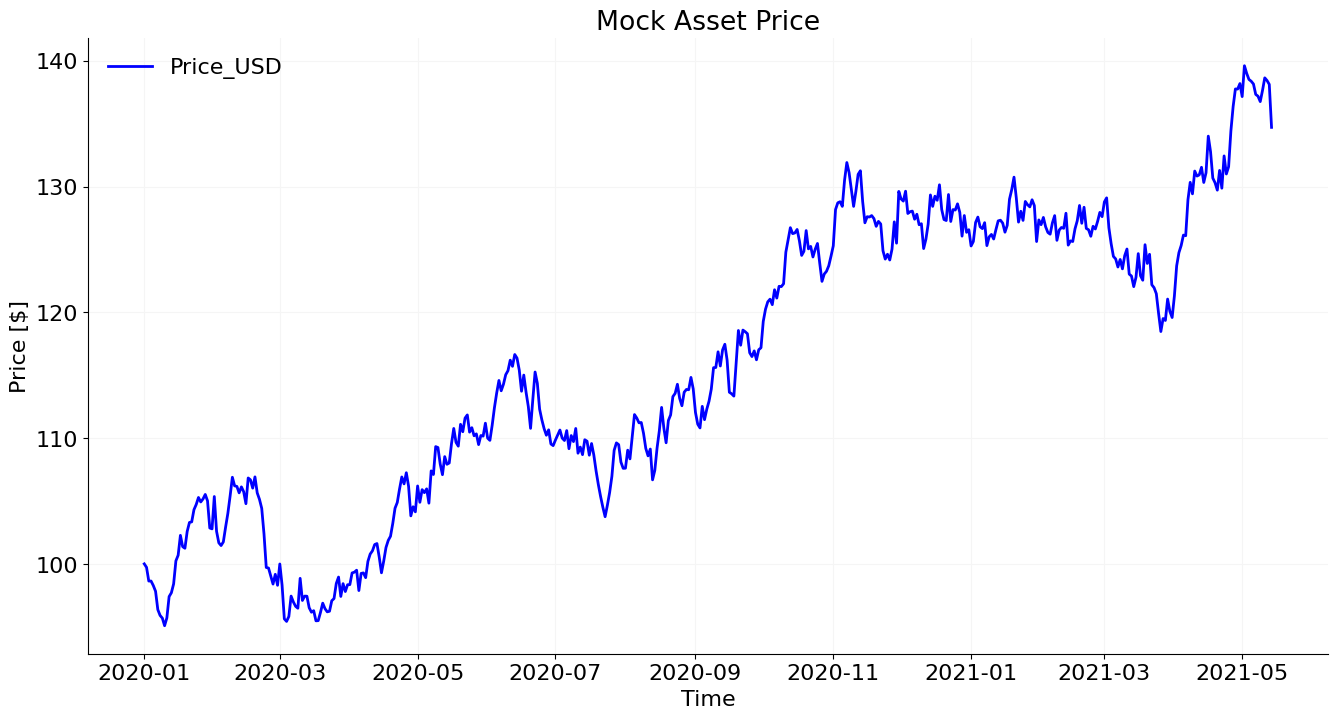

In [17]:
fig, ax = plot_data(data)

### User defined functions

In [18]:
def add_sma(df: pd.DataFrame, window: int=7) -> pd.DataFrame:
    """Calculate and add Simple Moving Average to the input df."""
    df[f"SMA_{window}"] = df["Price_USD"].rolling(window=window).mean()
    return df

In [19]:
def add_ema(df: pd.DataFrame, window: int=200) -> pd.DataFrame:
    """Calculate and add Exponential Moving Average to the input df."""
    df[f"EMA_{window}"] = df["Price_USD"].ewm(span=window, adjust=False).mean()
    return df

### Pipe with a for loop 1

In [20]:
windows = [7, 30]  # in days

for w in windows:
    df_final = (
        data
        .pipe(add_sma, window=w)
        .pipe(add_ema, window=w)
    )

In [21]:
df_final

,Price_USD,SMA_7,EMA_7,SMA_30,EMA_30
2020-01-01,100.016110,NaN,100.016110,NaN,100.016110
2020-01-02,99.741898,NaN,99.947557,NaN,99.998419
2020-01-03,98.649698,NaN,99.623092,NaN,99.911405
2020-01-04,98.651786,NaN,99.380266,NaN,99.830139
2020-01-05,98.293974,NaN,99.108693,NaN,99.731031
...,...,...,...,...,...
2021-05-10,137.640161,137.707808,137.487967,134.419636,134.444737
2021-05-11,138.643036,137.725711,137.776734,134.679874,134.715595
2021-05-12,138.432613,137.734011,137.940704,134.929925,134.955402
2021-05-13,138.122171,137.729582,137.986071,135.149494,135.159710


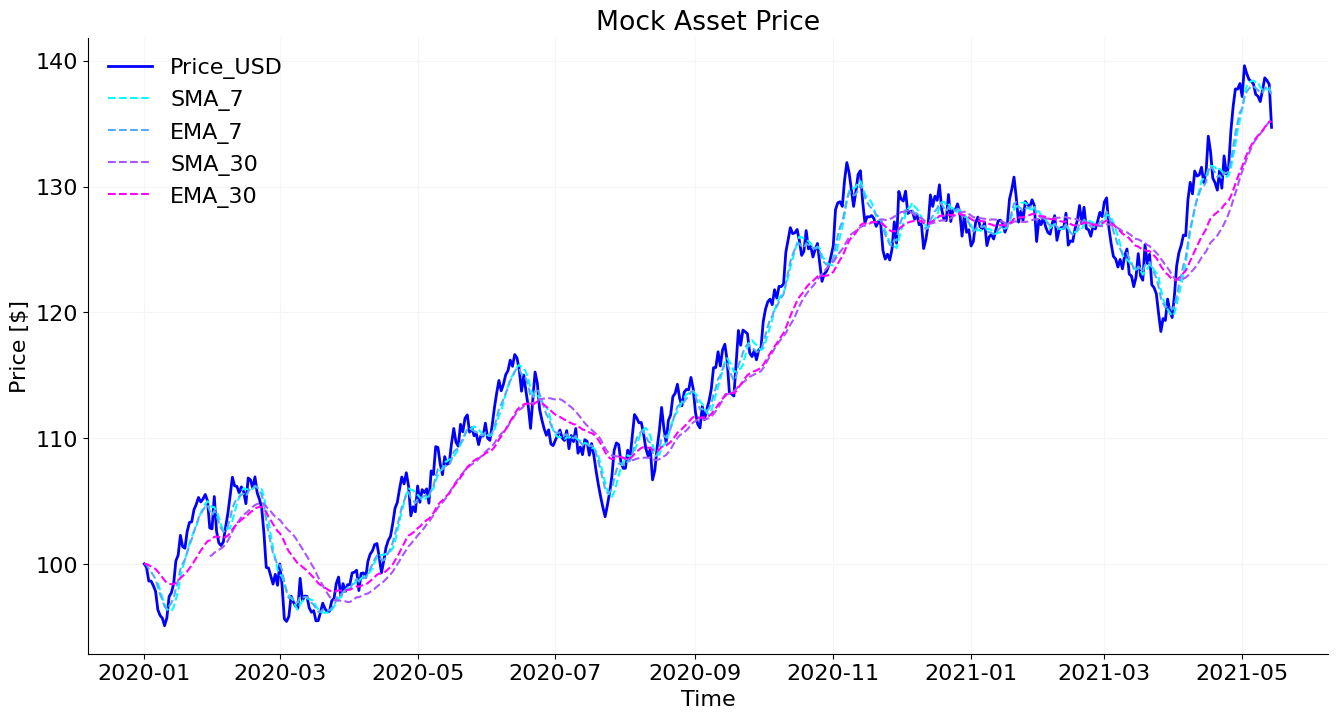

In [22]:
fig, ax = plot_data(data)
fig

### Pipe with a for loop 2

In [23]:
# Reset data
data = generate_stock_curve()

In [24]:
pipeline = [
    (add_sma, 7),
    (add_sma, 30),
    (add_ema, 30),
]

for func, w in pipeline:
    data = data.pipe(func, window=w)

In [25]:
data

,Price_USD,SMA_7,SMA_30,EMA_30
2020-01-01,100.016110,NaN,NaN,100.016110
2020-01-02,99.741898,NaN,NaN,99.998419
2020-01-03,98.649698,NaN,NaN,99.911405
2020-01-04,98.651786,NaN,NaN,99.830139
2020-01-05,98.293974,NaN,NaN,99.731031
...,...,...,...,...
2021-05-10,137.640161,137.707808,134.419636,134.444737
2021-05-11,138.643036,137.725711,134.679874,134.715595
2021-05-12,138.432613,137.734011,134.929925,134.955402
2021-05-13,138.122171,137.729582,135.149494,135.159710


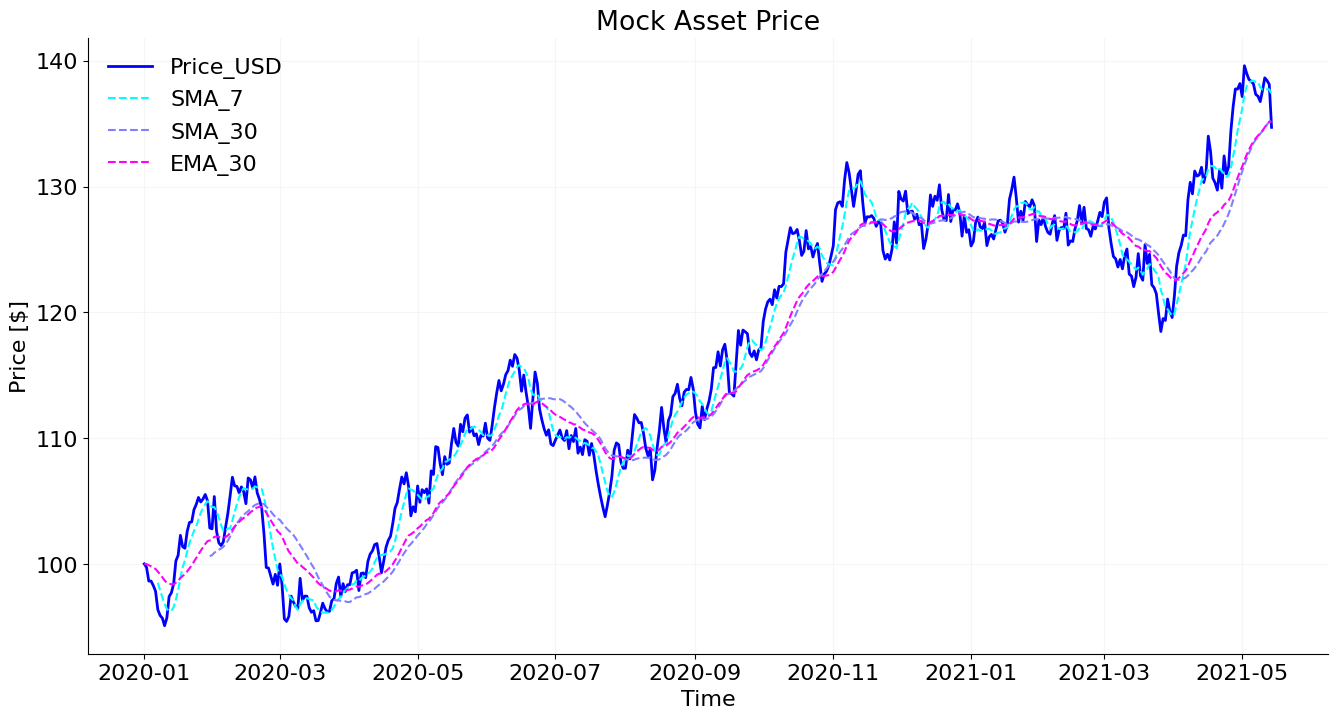

In [26]:
fig, ax = plot_data(data)
fig